## Project Overview
Financial institutions rely on customer financial behavior to assess credit risk and make informed lending decisions. This project analyzes customer banking data using Python to identify patterns in credit behavior, understand customer financial characteristics, and generate insights that support credit risk assessment, customer profiling, and data-driven lending decisions.

## Objectives 
The objective of this project is to analyze customer financial and behavioral data to identify the key factors influencing creditworthiness and financial risk. By leveraging Exploratory Data Analysis (EDA) and visualization techniques, the project aims to uncover meaningful patterns, relationships, and anomalies in customer financial behavior. The insights generated can help financial institutions improve credit risk assessment, strengthen customer profiling, support informed lending decisions, and identify unusual financial behavior that may require further investigation.

In [2]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

In [3]:
df = pd.read_csv(r"C:\Users\rebek\Downloads\dataset (1).csv")

In [4]:
df.head()

,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,5634,3392,1,Aaron Maashoh,23.0,821000265.0,Scientist,19114.12,1824.843333,3.0,...,Good,809.98,26.822620,265.0,No,49.574949,21.46538,High_spent_Small_value_payments,312.494089,Good
1,5635,3392,2,Aaron Maashoh,23.0,821000265.0,Scientist,19114.12,1824.843333,3.0,...,Good,809.98,31.944960,266.0,No,49.574949,21.46538,Low_spent_Large_value_payments,284.629162,Good
2,5636,3392,3,Aaron Maashoh,23.0,821000265.0,Scientist,19114.12,1824.843333,3.0,...,Good,809.98,28.609352,267.0,No,49.574949,21.46538,Low_spent_Medium_value_payments,331.209863,Good
3,5637,3392,4,Aaron Maashoh,23.0,821000265.0,Scientist,19114.12,1824.843333,3.0,...,Good,809.98,31.377862,268.0,No,49.574949,21.46538,Low_spent_Small_value_payments,223.451310,Good
4,5638,3392,5,Aaron Maashoh,23.0,821000265.0,Scientist,19114.12,1824.843333,3.0,...,Good,809.98,24.797347,269.0,No,49.574949,21.46538,High_spent_Medium_value_payments,341.489231,Good


In [5]:
# Dataset Rows & Columns count
df.shape

(100000, 28)

In [6]:
# Dataset Info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 28 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   ID                        100000 non-null  int64  
 1   Customer_ID               100000 non-null  int64  
 2   Month                     100000 non-null  int64  
 3   Name                      100000 non-null  object 
 4   Age                       100000 non-null  float64
 5   SSN                       100000 non-null  float64
 6   Occupation                100000 non-null  object 
 7   Annual_Income             100000 non-null  float64
 8   Monthly_Inhand_Salary     100000 non-null  float64
 9   Num_Bank_Accounts         100000 non-null  float64
 10  Num_Credit_Card           100000 non-null  float64
 11  Interest_Rate             100000 non-null  float64
 12  Num_of_Loan               100000 non-null  float64
 13  Type_of_Loan              100000 non-null  ob

In [7]:
# Dataset Duplicate Value Count
len(df[df.duplicated()])

0

In [8]:
# Missing Values/Null Values Count
df.isnull().sum()

ID                          0
Customer_ID                 0
Month                       0
Name                        0
Age                         0
SSN                         0
Occupation                  0
Annual_Income               0
Monthly_Inhand_Salary       0
Num_Bank_Accounts           0
Num_Credit_Card             0
Interest_Rate               0
Num_of_Loan                 0
Type_of_Loan                0
Delay_from_due_date         0
Num_of_Delayed_Payment      0
Changed_Credit_Limit        0
Num_Credit_Inquiries        0
Credit_Mix                  0
Outstanding_Debt            0
Credit_Utilization_Ratio    0
Credit_History_Age          0
Payment_of_Min_Amount       0
Total_EMI_per_month         0
Amount_invested_monthly     0
Payment_Behaviour           0
Monthly_Balance             0
Credit_Score                0
dtype: int64

In [9]:
# Dataset Columns
df.columns

Index(['ID', 'Customer_ID', 'Month', 'Name', 'Age', 'SSN', 'Occupation',
       'Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts',
       'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan', 'Type_of_Loan',
       'Delay_from_due_date', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit',
       'Num_Credit_Inquiries', 'Credit_Mix', 'Outstanding_Debt',
       'Credit_Utilization_Ratio', 'Credit_History_Age',
       'Payment_of_Min_Amount', 'Total_EMI_per_month',
       'Amount_invested_monthly', 'Payment_Behaviour', 'Monthly_Balance',
       'Credit_Score'],
      dtype='object')

In [10]:
# Dataset Describe
df.describe(include='all')

,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
count,100000.000000,100000.000000,100000.000000,100000,100000.000000,1.000000e+05,100000,100000.000000,100000.000000,100000.000000,...,100000,100000.000000,100000.000000,100000.000000,100000,100000.000000,100000.000000,100000,100000.000000,100000
unique,NaN,NaN,NaN,10128,NaN,NaN,15,NaN,NaN,NaN,...,3,NaN,NaN,NaN,3,NaN,NaN,6,NaN,3
top,NaN,NaN,NaN,Stevex,NaN,NaN,Lawyer,NaN,NaN,NaN,...,Standard,NaN,NaN,NaN,Yes,NaN,NaN,Low_spent_Small_value_payments,NaN,Standard
freq,NaN,NaN,NaN,48,NaN,NaN,7096,NaN,NaN,NaN,...,45848,NaN,NaN,NaN,52326,NaN,NaN,28616,NaN,53174
mean,80631.500000,25982.666640,4.500000,NaN,33.316340,5.004617e+08,NaN,50505.123449,4197.270835,5.368820,...,NaN,1426.220376,32.285173,221.220460,NaN,107.699208,55.101315,NaN,392.697586,NaN
std,43301.486619,14340.543051,2.291299,NaN,10.764812,2.908267e+08,NaN,38299.422093,3186.432497,2.593314,...,NaN,1155.129026,5.116875,99.680716,NaN,132.267056,39.006932,NaN,201.652719,NaN
min,5634.000000,1006.000000,1.000000,NaN,14.000000,8.134900e+04,NaN,7005.930000,303.645417,0.000000,...,NaN,0.230000,20.000000,1.000000,NaN,0.000000,0.000000,NaN,0.007760,NaN
25%,43132.750000,13664.500000,2.750000,NaN,24.000000,2.451686e+08,NaN,19342.972500,1626.594167,3.000000,...,NaN,566.072500,28.052567,144.000000,NaN,29.268886,27.959111,NaN,267.615983,NaN
50%,80631.500000,25777.000000,4.500000,NaN,33.000000,5.006886e+08,NaN,36999.705000,3095.905000,5.000000,...,NaN,1166.155000,32.305784,219.000000,NaN,66.462304,45.156550,NaN,333.865366,NaN
75%,118130.250000,38385.000000,6.250000,NaN,42.000000,7.560027e+08,NaN,71683.470000,5957.715000,7.000000,...,NaN,1945.962500,36.496663,302.000000,NaN,147.392573,71.295797,NaN,463.215683,NaN


In [11]:
# Check Unique Values for each variable.
df.nunique()

ID                          100000
Customer_ID                  12500
Month                            8
Name                         10128
Age                             43
SSN                          12500
Occupation                      15
Annual_Income                12488
Monthly_Inhand_Salary        13241
Num_Bank_Accounts               12
Num_Credit_Card                 12
Interest_Rate                   34
Num_of_Loan                     10
Type_of_Loan                  6261
Delay_from_due_date             63
Num_of_Delayed_Payment          26
Changed_Credit_Limit          3452
Num_Credit_Inquiries            18
Credit_Mix                       3
Outstanding_Debt             12203
Credit_Utilization_Ratio    100000
Credit_History_Age             404
Payment_of_Min_Amount            3
Total_EMI_per_month          11890
Amount_invested_monthly      12261
Payment_Behaviour                6
Monthly_Balance              98494
Credit_Score                     3
dtype: int64

In [ ]:
# Convert 'Age' column from float to integer
df['Age'] = df['Age'].astype(int)


Number of duplicate rows: 0


In [13]:
#Removing outliers in 'Annual_Income' column using IQR
Q1 = df['Annual_Income'].quantile(0.25)
Q3 = df['Annual_Income'].quantile(0.75)
IQR = Q3 - Q1
df = df[(df['Annual_Income'] >= (Q1 - 1.5 * IQR)) & (df['Annual_Income'] <= (Q3 + 1.5 * IQR))]

In [14]:
#Creating a new column 'Income_per_Account'
df['Income_per_Account'] = df['Annual_Income'] / df['Num_Bank_Accounts']

In [ ]:
#Average Age of Customers
avg_age = df['Age'].mean()
print(f"Average Age of Customers: {avg_age:.2f} years") 

Average Age of Customers: 33.27 years


In [ ]:
#Number of Customers by Income Group

# Define income groups (bins)
max_income = df['Annual_Income'].max()
bins = [0, 25000, 50000, 100000, 200000]

labels = ['Low (<25K)', 'Lower-Middle (25K-50K)',
          'Middle (50K-100K)', 'Upper-Middle (100K-200K)']
    
if max_income > 200000:
    bins.append(max_income)
    labels.append('High (>200K)')

# Create income group column
df['Income_Group'] = pd.cut(df['Annual_Income'], bins=bins, labels=labels, include_lowest=True)

# KPI: Number of customers by income group
income_group_counts = df['Income_Group'].value_counts().sort_index()

print(income_group_counts)

Income_Group
Low (<25K)                  33480
Lower-Middle (25K-50K)      27296
Middle (50K-100K)           26496
Upper-Middle (100K-200K)    10728
Name: count, dtype: int64


In [18]:
#Average Annual Income
avg_annual_income = df['Annual_Income'].mean()
print(f"Average Annual Income: ${avg_annual_income:.2f}")

Average Annual Income: $48146.02


In [19]:
#Average Monthly In-hand Salary
avg_monthly_salary = df['Monthly_Inhand_Salary'].mean()
print(f"Average Monthly In-hand Salary: ${avg_monthly_salary:.2f}")

Average Monthly In-hand Salary: $4001.08


In [20]:
#Average Debt-to-Income Ratio
debt_to_income_ratio = df['Outstanding_Debt'] / df['Annual_Income']
avg_debt_to_income_ratio = debt_to_income_ratio.mean()
print(f"Average Debt-to-Income Ratio: {avg_debt_to_income_ratio:.2f}")


Average Debt-to-Income Ratio: 0.06


In [21]:
#Average Credit Utilization Ratio
credit_utilization_ratio = df['Credit_Utilization_Ratio']
avg_credit_utilization_ratio = credit_utilization_ratio.mean()
print(f"Average Credit Utilization Ratio: {avg_credit_utilization_ratio:.2f}")

Average Credit Utilization Ratio: 32.22


In [22]:
#Average Number of Bank Accounts
avg_num_bank_accounts = df['Num_Bank_Accounts'].mean()
print(f"Average Number of Bank Accounts: {avg_num_bank_accounts:.2f}")

Average Number of Bank Accounts: 5.42


In [23]:
#Average Number of Credit Cards
avg_num_credit_cards = df['Num_Credit_Card'].mean()
print(f"Average Number of Credit Cards: {avg_num_credit_cards:.2f}")

Average Number of Credit Cards: 5.56


In [24]:
#Average Number of Loans per Customer
avg_num_loans = df['Num_of_Loan'].mean()
print(f"Average Number of Loans per Customer: {avg_num_loans:.2f}")

Average Number of Loans per Customer: 3.57


In [25]:
#Average Interest Rate
avg_interest_rate = df['Interest_Rate'].mean()
print(f"Average Interest Rate: {avg_interest_rate:.2f}%")

Average Interest Rate: 14.69%


In [26]:
#Total EMI as percentage of Income (EMI Burden Ratio)
total_emi = df['Total_EMI_per_month'].sum()
total_income = df['Monthly_Inhand_Salary'].sum()
emi_burden_ratio = (total_emi / total_income) * 100
print(f"Total EMI as % of Income (EMI Burden Ratio): {emi_burden_ratio:.2f}")

Total EMI as % of Income (EMI Burden Ratio): 2.63


In [27]:
df['Credit_History_Age'].head()

0    265.0
1    266.0
2    267.0
3    268.0
4    269.0
Name: Credit_History_Age, dtype: float64

In [28]:
#Average Credit History Age
avg_credit_history_age = df['Credit_History_Age'].mean()

avg_years = avg_credit_history_age / 12

print(f"Average Credit History Age: {avg_years:.2f} years")

Average Credit History Age: 18.31 years


In [29]:
#Average Number of Delayed Payments
avg_num_delayed_payments = df['Num_of_Delayed_Payment'].mean()
print(f"Average Number of Delayed Payments: {avg_num_delayed_payments:.2f}")

Average Number of Delayed Payments: 13.46


In [30]:
# Percentage of Customers with at Least One Credit Inquiry
percent_frequent_credit_inquiries = (df['Num_Credit_Inquiries'] > 0).mean() * 100
print(f"Percent of Customer with Frequent Credit Inquiries: {percent_frequent_credit_inquiries:.2f}%")

Percent of Customer with Frequent Credit Inquiries: 92.94%


In [31]:
#Distribution of Credit Score Categories(Good/Standard/Poor)
credit_score_counts = df['Credit_Score'].value_counts()
print("Distribution of Credit Score Categories:")
print(credit_score_counts)

Distribution of Credit Score Categories:
Credit_Score
Standard    52399
Poor        28678
Good        16923
Name: count, dtype: int64


In [33]:
Occupation_wise_no_of_customers = df['Occupation'].value_counts().reset_index()

In [34]:
Occupation_wise_no_of_customers

,Occupation,count
0,Lawyer,6960
1,Engineer,6720
2,Architect,6672
3,Mechanic,6648
4,Scientist,6624
5,Media_Manager,6600
6,Developer,6592
7,Accountant,6576
8,Teacher,6544
9,Entrepreneur,6496


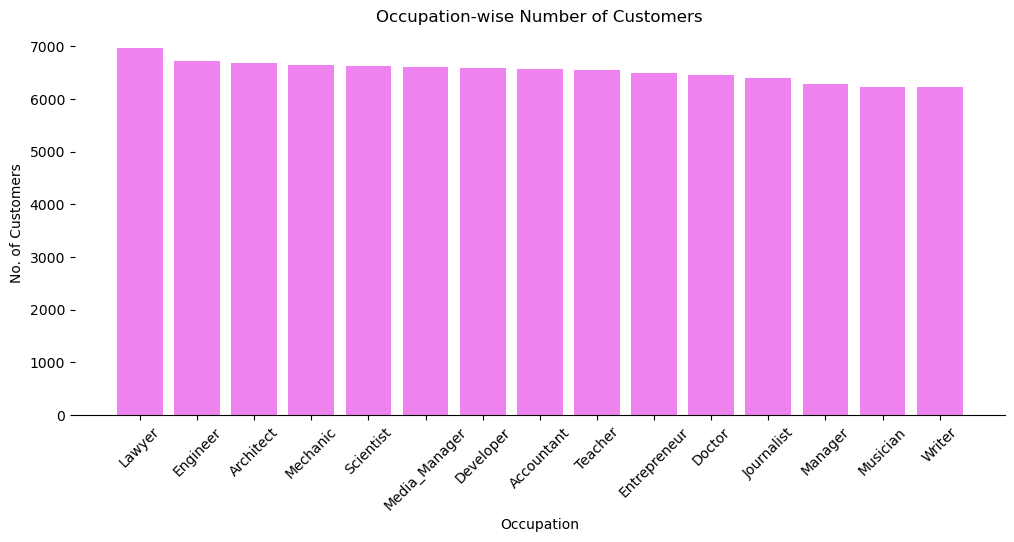

In [35]:
fig, ax = plt.subplots(figsize= (12,5))
ax.bar(x= Occupation_wise_no_of_customers['Occupation'].astype('str'), height = Occupation_wise_no_of_customers['count'], color = "violet")
ax.set_xlabel('Occupation')
ax.set_ylabel('No. of Customers')
ax.set_title('Occupation-wise Number of Customers')
ax.spines[['top', 'right', 'left']].set_visible(False)
plt.xticks(rotation=45)


plt.show()

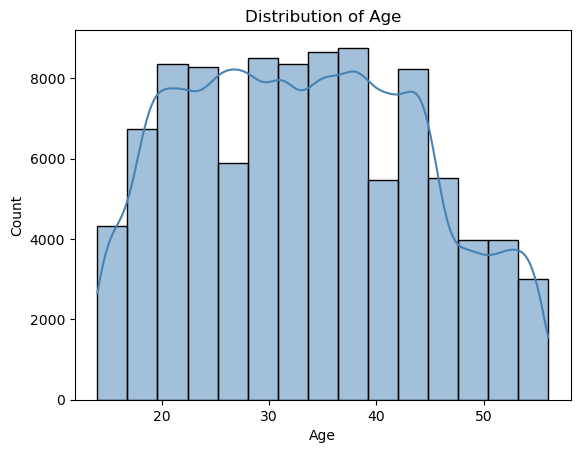

In [36]:
sns.histplot(df['Age'],bins=15, kde=True, color='steelblue')
plt.title('Distribution of Age')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

In [37]:
Occupation_wise_income = df.groupby('Occupation')['Annual_Income'].mean().reset_index()

In [38]:
Occupation_wise_income

,Occupation,Annual_Income
0,Accountant,47775.550517
1,Architect,49218.354041
2,Developer,47853.181796
3,Doctor,47440.318030
4,Engineer,48293.194994
5,Entrepreneur,48308.629637
6,Journalist,45805.598992
7,Lawyer,47313.386563
8,Manager,48905.160770
9,Mechanic,47880.823893


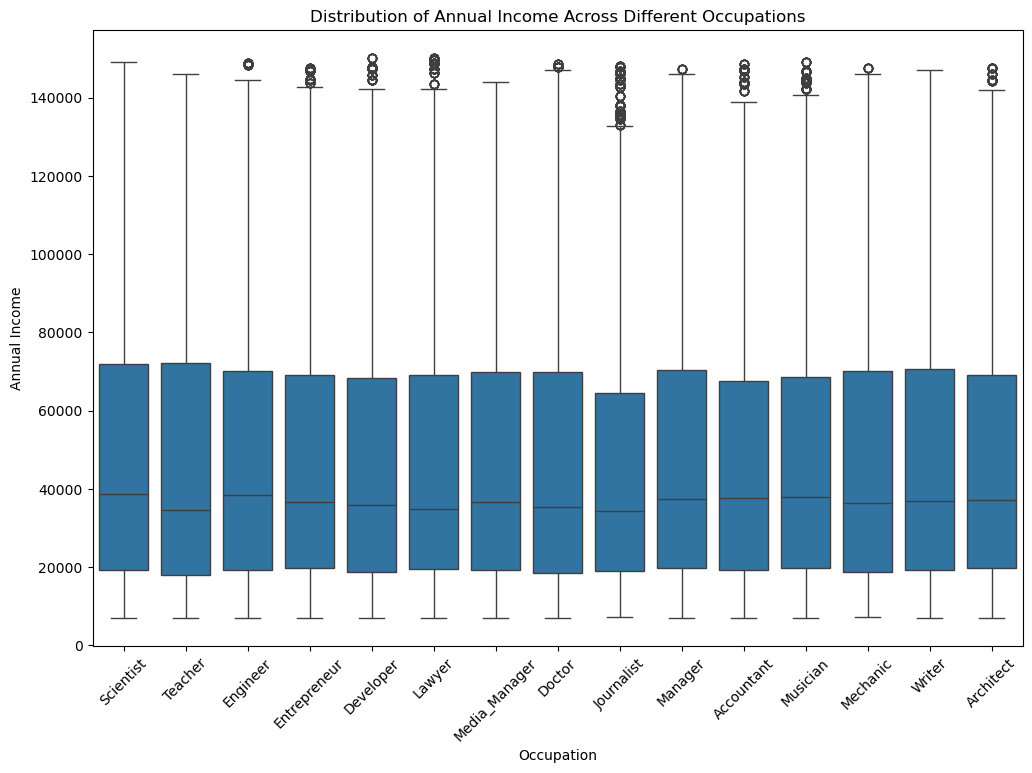

In [39]:
# Create a box plot for Annual Income across Occupation
plt.figure(figsize=(12, 8))
sns.boxplot(x='Occupation', y='Annual_Income', data=df)
plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
plt.title('Distribution of Annual Income Across Different Occupations')
plt.xlabel('Occupation')
plt.ylabel('Annual Income')
plt.show()


plt.show()

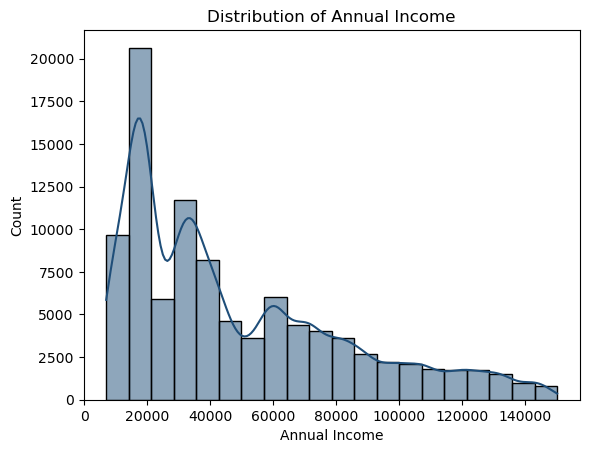

In [47]:
sns.histplot(
    df['Annual_Income'],
    bins=20,
    kde=True,
    color='#1f4e79',
    edgecolor='black'
)
plt.title("Distribution of Annual Income")
plt.xlabel("Annual Income")
plt.ylabel("Count")
plt.show()

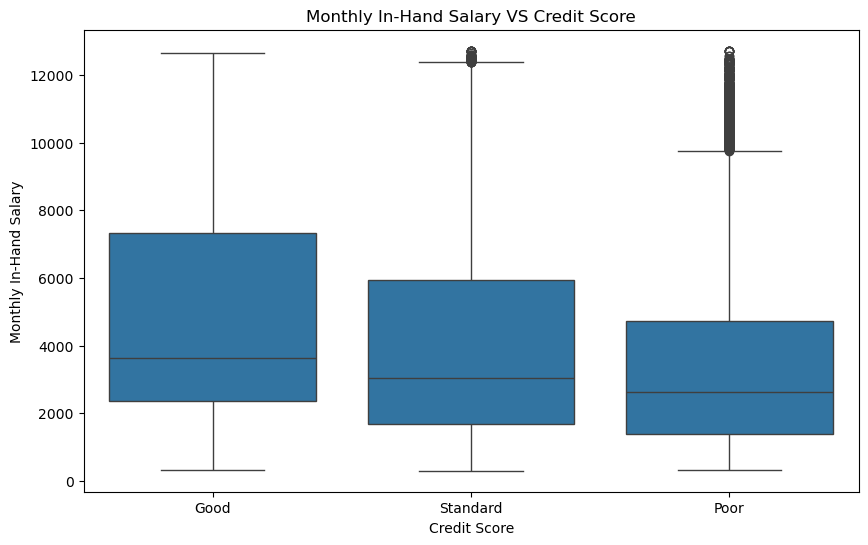

In [50]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Credit_Score', y='Monthly_Inhand_Salary', data= df)
plt.title('Monthly In-Hand Salary VS Credit Score')
plt.xlabel('Credit Score')
plt.ylabel('Monthly In-Hand Salary')
plt.show()


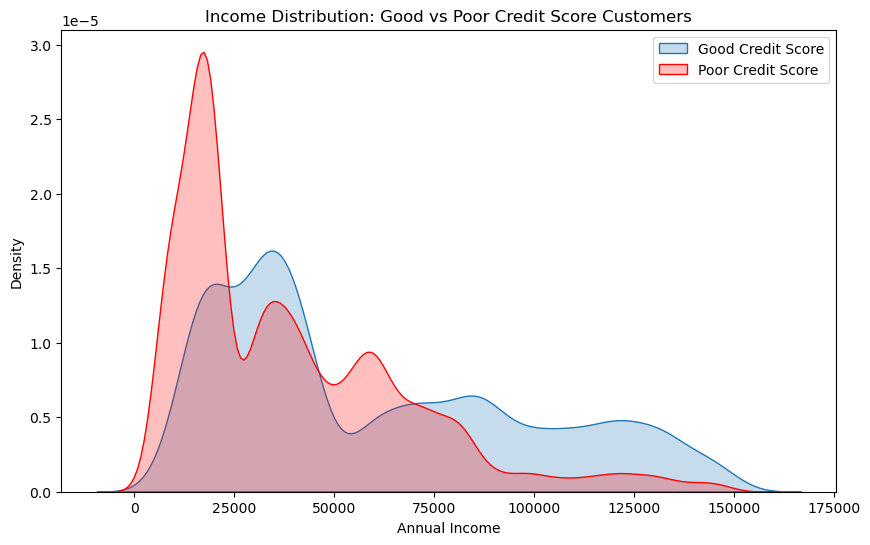

In [53]:
#Compare Income Distribution of Good VS Poor Credit Score Customers - KDE plot
plt.figure(figsize=(10, 6))

# KDE plot for Good credit score customers
sns.kdeplot(df[df['Credit_Score'] == 'Good']['Annual_Income'],
            label='Good Credit Score', fill=True)

# KDE plot for Poor credit score customers
sns.kdeplot(df[df['Credit_Score'] == 'Poor']['Annual_Income'],
            label='Poor Credit Score', fill=True, color='red')

plt.title("Income Distribution: Good vs Poor Credit Score Customers")
plt.xlabel("Annual Income")
plt.ylabel("Density")
plt.legend()
plt.show()

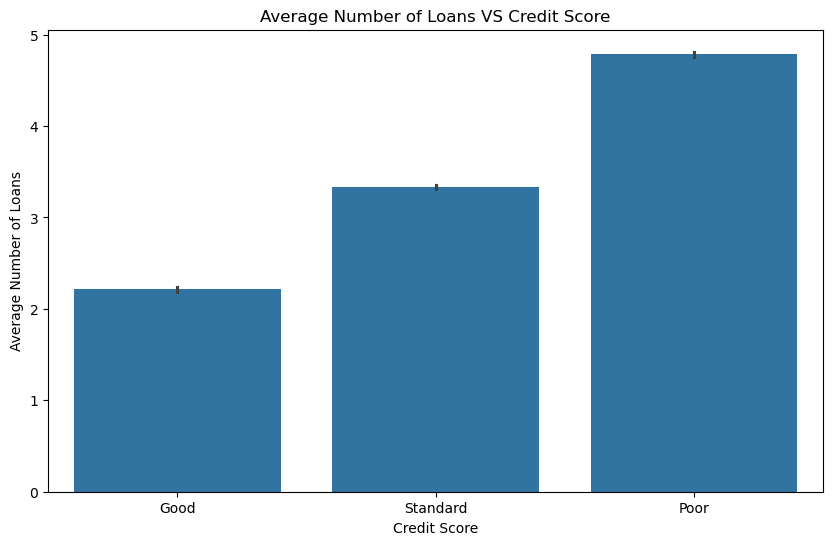

In [54]:
#Average Number of Loans VS Credit Score - Bar Chart
plt.figure(figsize=(10, 6))
sns.barplot(x='Credit_Score', y='Num_of_Loan', data=df)
plt.title('Average Number of Loans VS Credit Score')
plt.xlabel('Credit Score')
plt.ylabel('Average Number of Loans')
plt.show()

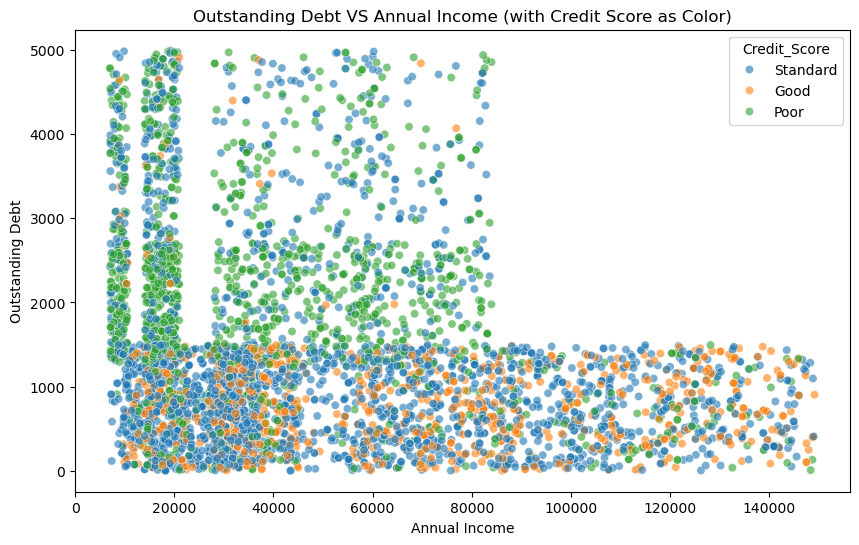

In [57]:
plt.figure(figsize=(10, 6))
sample_df = df.sample(5000, random_state=42)

sns.scatterplot(
    x='Annual_Income',
    y='Outstanding_Debt',
    hue='Credit_Score',
    data=sample_df,
    alpha=0.6
)
plt.title('Outstanding Debt VS Annual Income (with Credit Score as Color)')
plt.xlabel('Annual Income')
plt.ylabel('Outstanding Debt')
plt.show()

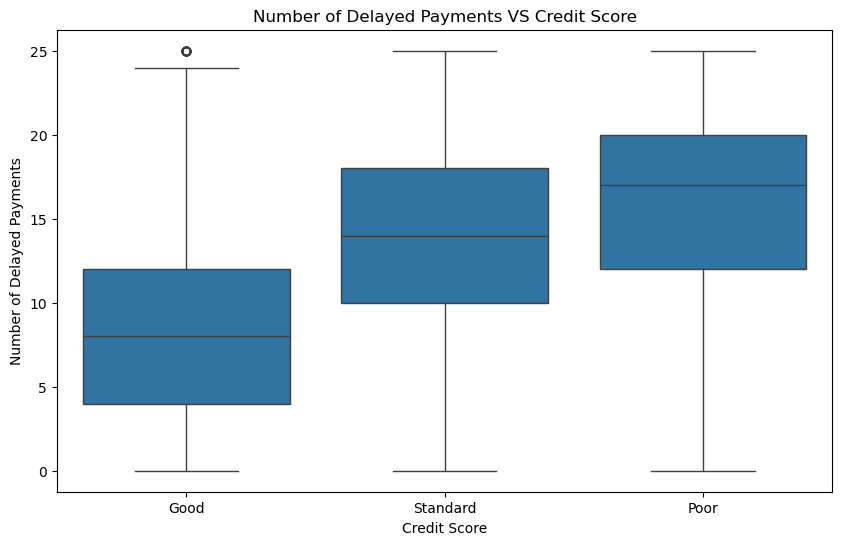

In [59]:
#Number of Delayed Payments VS Credit Score - Box Plot
plt.figure(figsize=(10, 6))
sns.boxplot(x='Credit_Score', y='Num_of_Delayed_Payment', data=df)
plt.title('Number of Delayed Payments VS Credit Score')
plt.xlabel('Credit Score')
plt.ylabel('Number of Delayed Payments')
plt.show()

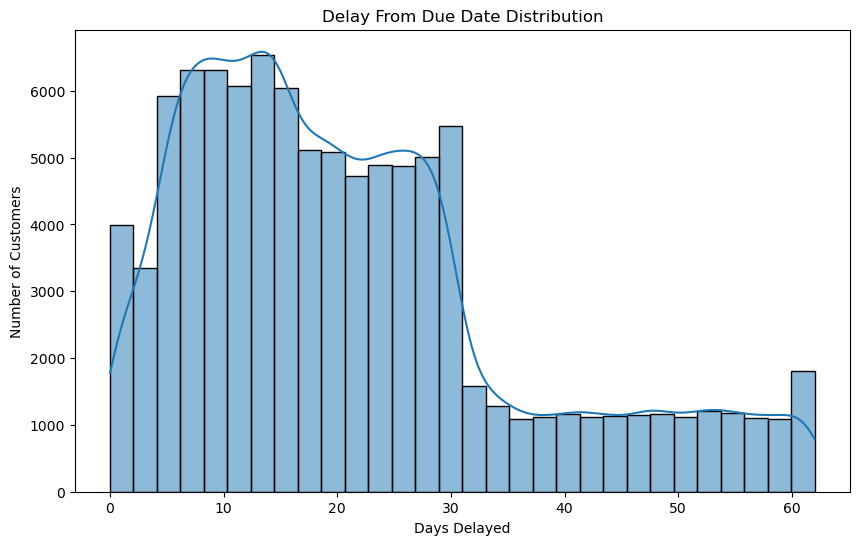

In [60]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Delay_from_due_date'], bins=30, edgecolor = 'black', kde=True)
plt.title('Delay From Due Date Distribution')
plt.xlabel('Days Delayed')
plt.ylabel('Number of Customers')
plt.show()

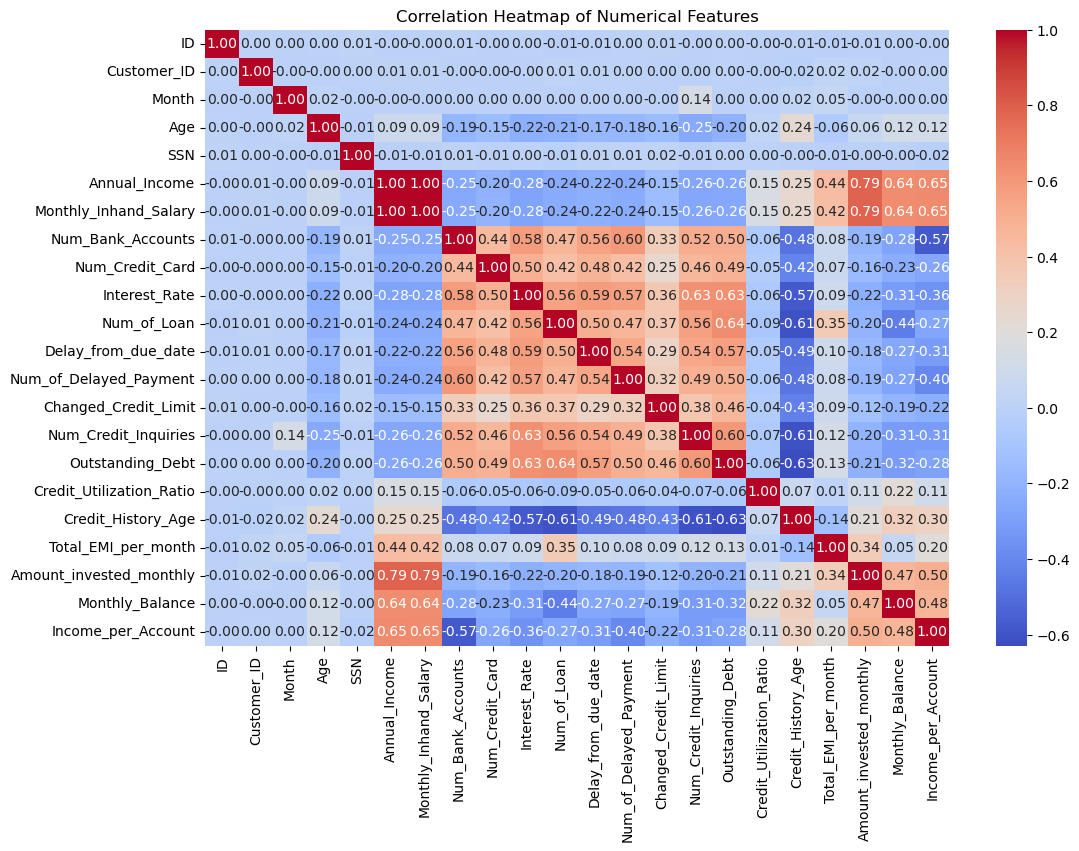

In [53]:
# Select only numerical features
num_df = df.select_dtypes(include=['int64', 'float64'])

# Compute correlation matrix
corr = num_df.corr()

# Plot heatmap
plt.figure(figsize=(12,8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)

plt.title("Correlation Heatmap of Numerical Features")
plt.show()

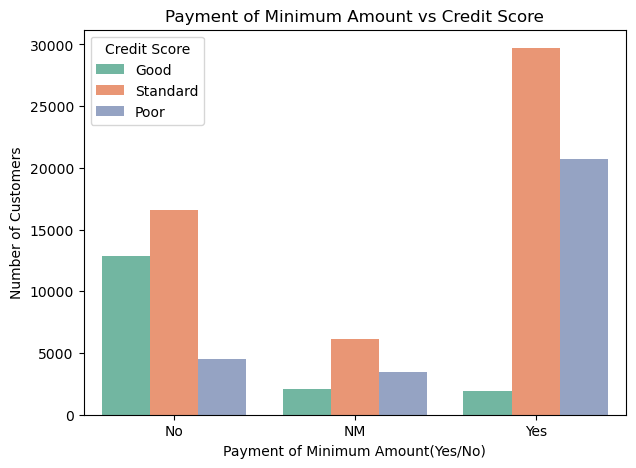

In [55]:
#Payment of Minimum Amount(Yes/No) VS Credit Score - Bar Chart
plt.figure(figsize=(7,5))

sns.countplot(data=df, x='Payment_of_Min_Amount', hue='Credit_Score', palette='Set2')

plt.title("Payment of Minimum Amount vs Credit Score")
plt.xlabel("Payment of Minimum Amount(Yes/No)")
plt.ylabel("Number of Customers")
plt.legend(title="Credit Score")
plt.show()

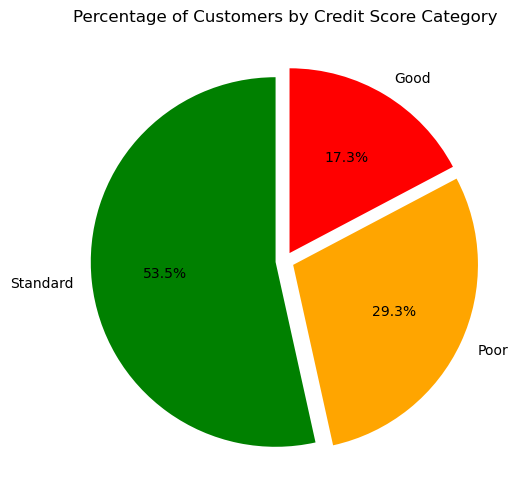

In [57]:
# Count customers in each credit score category
credit_score_counts = df['Credit_Score'].value_counts()

# Pie chart
plt.figure(figsize=(6,6))
plt.pie(credit_score_counts,
        labels=credit_score_counts.index,
         autopct='%1.1f%%',
         startangle=90,
        colors=['green', 'orange', 'red'],
        explode=(0.05, 0.05, 0.05))  # slight separation for clarity

plt.title("Percentage of Customers by Credit Score Category")
plt.show()


## Conclusion

This project analyzed customer financial and credit behavior using data cleaning, exploratory data analysis (EDA), and visualizations to uncover key patterns. The analysis showed that repayment behavior, credit utilization ratio, EMI, and outstanding debt are stronger indicators of creditworthiness than income alone. Customers with high utilization, delayed payments, and minimum due payments consistently exhibited poorer credit performance and higher financial risk. These insights can help financial institutions improve credit risk assessment, identify high-risk customers early, and make more informed lending decisions.

The findings of this analysis demonstrate how data-driven insights can support financial institutions in improving customer profiling and making more accurate lending decisions. By identifying high-risk financial behaviors at an early stage, organizations can reduce potential credit losses, strengthen risk management strategies, and enhance overall decision-making. In the future, this analysis can be extended by integrating machine learning models to predict customer credit risk and detect anomalous financial behavior more effectively.